# 23 - Ray Tracing With Conformal Geometry

This notebook is a standalone, executable replacement for Chapter 23, "Using the Geometry in a Ray-Tracing Application." It follows the seed style used in this repository: the chapter opens with the idea, translates the mathematical language into code-level objects, gives a route through the material, imports a helper module, builds visuals, works examples, runs applied labs, and ends with sanity checks and takeaways.

The chapter is an application chapter. That matters. We are not only asking whether a representation is elegant; we are asking whether it supports a whole rendering pipeline. A ray tracer starts with a camera and an image grid. Each pixel spawns a ray. The ray is tested against models. Models are triangular meshes because triangles are reliable primitives for intersection, normal interpolation, material lookup, and spatial indexing. The closest hit becomes a surface point. That point asks new geometric questions: which lights are visible, what normal should be used, which reflected direction should be spawned, and how much color returns to the pixel?

Conformal geometric algebra gives a common language for many of those objects. Points, planes, lines, spheres, transformations, reflections, and incidence tests can be described in one model. The practical lesson is more subtle than "store every hot-path value as the richest possible algebraic object." Rendering is repetitive. If a value is read millions of times, the cheapest representation that preserves the intended geometry may be the right engineering choice. This notebook therefore uses conformal ideas as the organizing map while implementing many operations with direct NumPy stand-ins: a ray is an origin plus a unit direction, a triangle is three vertex indices, a bounding sphere is a fast rejection object, and a BSP tree is a reusable set of spatial decisions.

The final lab renders a small image from procedural triangular meshes. The renderer includes bounding-sphere rejection, BSP traversal, ray-triangle intersection, barycentric normal interpolation, shadows, and one reflected bounce. The image is intentionally small so the notebook remains quick to execute, but the geometry is live code that you can inspect and change.


## Source Span And Scope

The source PDF was checked before writing. The table of contents places Chapter 23 at printed page 557. `pdftotext` shows printed page 557 on PDF page 577 and printed page 581 on PDF page 601. The next extractable page, PDF page 602, starts Appendix A at printed page 585. In this PDF there are no extractable printed pages 582, 583, or 584 between the end of Chapter 23 and Appendix A.

The verified extraction span used here is therefore PDF pages 577-601, covering printed pages 557-581, with the requested printed range 557-584 treated as the authoritative chapter neighborhood. The visible topics in that span are ray-tracing basics, the high-level algorithm, triangular mesh representation, scene modeling and transformations, ray representation and spawning, ray-model intersection, BSP traversal, reflection and refraction directions, shading, and evaluation of representational tradeoffs.

This notebook is original exposition. It does not copy the textbook prose, code listings, captions, or exercises. The examples are generated locally, and the implementation is deliberately compact enough to audit.


## The Chapter Idea

A ray tracer is a conversation between geometry and bookkeeping. The image starts as a rectangular grid. Each pixel creates an oriented query into the scene. The query either misses, in which case the background color is returned, or it hits a surface. A hit is not just a point. It is a point on a model, at a distance along a ray, inside a particular triangle, with barycentric coordinates, an interpolated normal, and a material. The shader then turns that local geometric data into color.

The conformal model is useful because the objects in this conversation are all geometric. A point can be lifted to a null vector. A sphere can reject rays before expensive mesh tests. A plane can define a reflection. A line or ray can be built from points and the point at infinity. Transformations can act on whole objects. This lets a programmer reason in terms of objects and relationships rather than only in terms of arrays.

But the application also teaches restraint. A renderer spends most of its time in inner loops. A universal representation is not automatically the best storage format for every loop. If the shader needs dot products of ordinary directions, Euclidean vectors are excellent. If the intersection routine needs the nearest positive parameter, a point-direction ray is excellent. If the mesh needs repeated access to positions, vertex arrays are excellent. The algebra names the geometry and suggests invariants; the implementation chooses forms that keep repeated questions cheap.


A useful way to read the whole chapter is as a sequence of narrowing questions. The camera asks a broad question: what lies along this viewing direction? The bounding sphere asks a cheaper preliminary question: could this model be involved at all? The BSP asks a spatial question: which small region of the model can the ray segment enter first? The triangle test asks an exact local question: does the ray meet this patch, and with which barycentric weights? The shader asks a physical-looking but approximate question: given this local attitude and material, which light paths are available and which outgoing direction reaches the viewer? Each stage keeps only the data needed by the next stage. That is why the notebook treats representation as part of the geometry rather than as a separate programming afterthought.


## Translation Guide

| Ray-tracing idea | Conformal-geometric reading | Coordinate stand-in used here |
|---|---|---|
| Euclidean point | Null conformal point | NumPy `[x, y, z]`, plus a compact `cga_point` check |
| Mesh vertex | Position and local surface attitude | Position row plus averaged vertex normal |
| Triangle face | Oriented surface patch | Three vertex indices, face normal, barycentric coordinates |
| Model | Object transformed into scene space | `TriangleMesh` with world-space vertices |
| Ray | Oriented line query | `Ray(origin, direction, t_min, t_max)` |
| Bounding sphere | Round enclosing primitive | Center and radius used for rejection |
| BSP node | Spatial split into two half-spaces | Axis-aligned split plane and child boxes |
| Intersection | Incidence plus closest positive parameter | Moller-Trumbore test returning `t` and barycentric weights |
| Surface attitude | Normal or tangent information at a hit | Interpolated unit normal |
| Shading | Angles, visibility, material response | Ambient, diffuse, specular, shadows, reflection |

The stand-ins are deliberate. The conformal reading tells us what each object means. The arrays make the executable lab short and fast.


## Notebook Route

1. Import the helper module and create stable artifact paths under `artifacts/chapter-23/`.
2. Build a procedural scene and verify the conformal distance identity.
3. Visualize meshes, wireframes, normals, and bounding spheres.
4. Treat scene modeling as object transformation and check preserved lengths.
5. Spawn camera rays and inspect their geometry.
6. Work a single ray-triangle intersection with barycentric coordinates.
7. Build and visualize a BSP tree, then compare it with naive triangle traversal.
8. Compute surface normals, shadow rays, reflection, refraction, and local shading.
9. Render a small image artifact and run final sanity checks.

The helper code lives in `utils/chapter23_ray_tracing.py`. The notebook is meant to be edited. Increase mesh tessellation, move the camera, disable the BSP, and rerun the checks to see which invariants survive.


In [1]:
from __future__ import annotations

from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go

BOOK_ROOT = Path.cwd()
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils" / "chapter23_ray_tracing.py").exists():
        BOOK_ROOT = candidate
        break

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import artifact_path, display_artifact, save_json, save_matplotlib, save_plotly_html
from utils.chapter23_ray_tracing import (
    IntersectStats,
    Material,
    Ray,
    TriangleMesh,
    barycentric_point,
    box_mesh,
    bsp_leaf_count,
    bsp_nodes,
    build_bsp_tree,
    camera_rays,
    cga_distance_squared,
    cga_inner,
    cga_point,
    demo_scene,
    intersect_scene,
    mesh_edge_segments,
    normalize,
    ray_sphere_interval,
    ray_triangle_intersection,
    reflect_direction,
    refract_direction,
    render_scene,
    representative_bsp_planes,
    rotation_matrix,
    shade_hit,
)


ARTIFACT_ROOT = BOOK_ROOT / "artifacts"
CHAPTER_ARTIFACT_DIR = ARTIFACT_ROOT / "chapter-23"
CHAPTER_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (7, 4.8), "axes.grid": True})
written_artifacts: dict[str, Path] = {}


def remember(name: str, path: Path) -> Path:
    written_artifacts[name] = path
    print(f"{name}: {path.relative_to(BOOK_ROOT).as_posix()}")
    return path


## Shared Helpers And Procedural Scene

The helper module does not implement a complete conformal algebra. It implements the application objects needed here: rays, materials, lights, triangular meshes, bounding spheres, a BSP tree, intersection routines, a camera, a shader, and a small renderer. It also includes a compact conformal point lift for the distance identity `P(x).P(y) = -0.5 ||x-y||^2`. That check lets the notebook keep one foot in the conformal model while the renderer uses efficient arrays.

The procedural scene has three meshes. The red object is a triangular approximation to a sphere, not an analytic sphere. The blue object is a rotated box. The floor is two triangles. This is enough to exercise smooth normals, flat faces, shadows, reflection, and spatial acceleration without loading external assets.


In [2]:
meshes, lights, camera = demo_scene()
for mesh in meshes:
    center, radius = mesh.bounding_sphere()
    b_min, b_max = mesh.bounds()
    print(
        {
            "name": mesh.name,
            "vertices": int(mesh.vertices.shape[0]),
            "triangles": mesh.triangle_count,
            "bounds_min": b_min.round(3).tolist(),
            "bounds_max": b_max.round(3).tolist(),
            "sphere_radius": round(radius, 3),
        }
    )

a = np.array([1.0, -0.25, 0.5])
b = np.array([-0.5, 0.75, 1.25])
assert np.isclose(cga_distance_squared(a, b), np.sum((a - b) ** 2))
assert np.isclose(cga_inner(cga_point(a), cga_point(a)), 0.0)
print("conformal recovered squared distance:", cga_distance_squared(a, b))


{'name': 'red sphere mesh', 'vertices': 266, 'triangles': 528, 'bounds_min': [-1.54, -0.97, -0.77], 'bounds_max': [0.1, 0.67, 0.87], 'sphere_radius': 0.82}
{'name': 'blue box mesh', 'vertices': 8, 'triangles': 12, 'bounds_min': [0.255, -0.945, -0.47], 'bounds_max': [1.453, 0.105, 0.728], 'sphere_radius': 0.836}
{'name': 'ground', 'vertices': 4, 'triangles': 2, 'bounds_min': [-3.0, -1.0, -3.0], 'bounds_max': [3.0, -1.0, 3.0], 'sphere_radius': 4.243}
conformal recovered squared distance: 3.8125


## Mesh Representation

A triangular mesh separates vertex data from face data. Vertex positions are stored once. Faces store integer indices into that vertex array. The split is useful because neighboring triangles can share positions and because per-vertex data, such as normals or texture coordinates, can be interpolated at a hit point. In conformal language, the position is the point and the normal is a local surface attitude attached to that point. In a renderer, both are arrays because the shader reads them repeatedly.

Faces are the actual intersection primitives. Each face has an orientation determined by vertex order, a face normal determined by a cross product, and a triangle area. Vertex normals may differ from face normals. That is how a faceted mesh can shade like a smooth object while still intersecting as triangles. This is a classic rendering compromise: the geometry is polygonal, but the lighting model is allowed to interpolate a smoother attitude.

The visual below writes an interactive HTML artifact. The colored surfaces are meshes, the black lines are wireframe edges, and the translucent grey surfaces are bounding spheres. A bounding sphere is conservative. Missing it proves the mesh is missed; hitting it only says the detailed triangle tests are worth considering.


In [3]:
def mesh_surface_trace(mesh: TriangleMesh, opacity: float = 0.72) -> go.Mesh3d:
    rgb = np.round(mesh.material.color * 255).astype(int)
    return go.Mesh3d(
        x=mesh.vertices[:, 0],
        y=mesh.vertices[:, 1],
        z=mesh.vertices[:, 2],
        i=mesh.faces[:, 0],
        j=mesh.faces[:, 1],
        k=mesh.faces[:, 2],
        color=f"rgb({rgb[0]},{rgb[1]},{rgb[2]})",
        opacity=opacity,
        name=mesh.name,
    )


def edge_trace(mesh: TriangleMesh) -> go.Scatter3d:
    segments = mesh_edge_segments(mesh)
    xs, ys, zs = [], [], []
    for start, end in segments:
        xs.extend([start[0], end[0], None])
        ys.extend([start[1], end[1], None])
        zs.extend([start[2], end[2], None])
    return go.Scatter3d(
        x=xs, y=ys, z=zs, mode="lines", name=f"{mesh.name} edges",
        line={"color": "rgba(20,20,20,0.55)", "width": 2}
    )


def sphere_trace(center: np.ndarray, radius: float, name: str) -> go.Surface:
    u = np.linspace(0, 2 * np.pi, 32)
    v = np.linspace(0, np.pi, 16)
    x = center[0] + radius * np.outer(np.cos(u), np.sin(v))
    y = center[1] + radius * np.outer(np.sin(u), np.sin(v))
    z = center[2] + radius * np.outer(np.ones_like(u), np.cos(v))
    return go.Surface(
        x=x, y=y, z=z, opacity=0.12, showscale=False, name=name,
        colorscale=[[0, "#888888"], [1, "#888888"]], hoverinfo="skip"
    )


fig_mesh = go.Figure()
for mesh in meshes:
    fig_mesh.add_trace(mesh_surface_trace(mesh))
    fig_mesh.add_trace(edge_trace(mesh))
    center, radius = mesh.bounding_sphere()
    fig_mesh.add_trace(sphere_trace(center, radius, f"{mesh.name} bounding sphere"))
fig_mesh.update_layout(
    title="Meshes, wireframes, and bounding spheres",
    scene={"aspectmode": "data"},
    margin={"l": 0, "r": 0, "b": 0, "t": 45},
)
mesh_html = remember(
    "mesh_overview_html",
    save_plotly_html(fig_mesh, "chapter-23", "figures", "mesh-overview.html", root=ARTIFACT_ROOT),
)
display_artifact(mesh_html, height=540)


mesh_overview_html: artifacts/chapter-23/figures/mesh-overview.html


## Mesh Checks

The mesh arrays must still behave like geometric objects. Face areas should be positive. Face normals and vertex normals should be unit length. Every vertex should lie inside its bounding sphere. These checks are small, but they save a lot of confusion. A bad normal can masquerade as a shading bug. A degenerate triangle can masquerade as an intersection bug. A bounding sphere that is too small can hide a correct triangle hit before the triangle is ever tested.


In [4]:
mesh_checks = {}
for mesh in meshes:
    center, radius = mesh.bounding_sphere()
    vertex_distances = np.linalg.norm(mesh.vertices - center, axis=1)
    checks = {
        "min_face_area": float(mesh.face_areas.min()),
        "max_face_normal_error": float(np.max(np.abs(np.linalg.norm(mesh.face_normals, axis=1) - 1.0))),
        "max_vertex_normal_error": float(np.max(np.abs(np.linalg.norm(mesh.vertex_normals, axis=1) - 1.0))),
        "bounding_sphere_slack": float(radius - vertex_distances.max()),
    }
    mesh_checks[mesh.name] = checks
    print(mesh.name, checks)
    assert checks["min_face_area"] > 0
    assert checks["max_face_normal_error"] < 1e-9
    assert checks["max_vertex_normal_error"] < 1e-9
    assert checks["bounding_sphere_slack"] >= -1e-9

remember("mesh_checks_json", save_json(mesh_checks, "chapter-23", "checks", "mesh-checks.json", root=ARTIFACT_ROOT))


red sphere mesh {'min_face_area': 0.005880062567798993, 'max_face_normal_error': 2.220446049250313e-16, 'max_vertex_normal_error': 2.220446049250313e-16, 'bounding_sphere_slack': 0.0}
blue box mesh {'min_face_area': 0.4231999999999999, 'max_face_normal_error': 1.1102230246251565e-16, 'max_vertex_normal_error': 0.0, 'bounding_sphere_slack': 0.0}
ground {'min_face_area': 18.0, 'max_face_normal_error': 0.0, 'max_vertex_normal_error': 0.0, 'bounding_sphere_slack': 0.0}
mesh_checks_json: artifacts/chapter-23/checks/mesh-checks.json


WindowsPath('D:/Geometry/Geometric-Algebra-for-Computer-Science/artifacts/chapter-23/checks/mesh-checks.json')

## Scene Modeling As Object Transformation

Models are commonly authored in local coordinates and then placed in a world scene. In a conformal implementation, rotations and translations can be expressed as versors acting on whole objects. The helper uses a rotation matrix for the numerical operation, but the idea is the same: transform the object once, then trace rays against the transformed scene.

The check below rotates and translates a box. Rigid motion should preserve edge lengths and bounding-sphere radius. This is the modeling-side invariant. It runs before rendering and is separate from the hot ray-intersection loop. That separation is useful: modeling code can be expressive, while tracing code can use the already transformed world-space arrays.


In [5]:
local_box = box_mesh(center=(0, 0, 0), size=(0.92, 1.05, 0.92), material=Material(np.array([0.14, 0.38, 0.78])), name="local box")
world_box = local_box.transformed(
    matrix=rotation_matrix((0, 1, 0), np.deg2rad(-22.0)),
    translation=(0.84, -0.42, -0.20),
    name="world box",
)
local_lengths = np.sort(np.linalg.norm(mesh_edge_segments(local_box)[:, 1] - mesh_edge_segments(local_box)[:, 0], axis=1))
world_lengths = np.sort(np.linalg.norm(mesh_edge_segments(world_box)[:, 1] - mesh_edge_segments(world_box)[:, 0], axis=1))
assert np.max(np.abs(local_lengths - world_lengths)) < 1e-9
assert np.isclose(local_box.bounding_sphere()[1], world_box.bounding_sphere()[1])

fig_transform = go.Figure()
fig_transform.add_trace(mesh_surface_trace(local_box, opacity=0.35))
fig_transform.add_trace(edge_trace(local_box))
fig_transform.add_trace(mesh_surface_trace(world_box, opacity=0.72))
fig_transform.add_trace(edge_trace(world_box))
fig_transform.update_layout(title="Local box and transformed world-space box", scene={"aspectmode": "data"}, margin={"l": 0, "r": 0, "b": 0, "t": 45})
transform_html = remember(
    "scene_transform_html",
    save_plotly_html(fig_transform, "chapter-23", "figures", "scene-transform.html", root=ARTIFACT_ROOT),
)
display_artifact(transform_html, height=500)


scene_transform_html: artifacts/chapter-23/figures/scene-transform.html


## Camera Rays

The camera is a ray factory. A pinhole camera has an origin, a target, an up direction, a field of view, and an image aspect ratio. For each pixel, it constructs a direction through an imaginary image plane. The ray is then an oriented query into the scene.

The conformal model has several possible line representations. The renderer uses a point-direction pair because closest-hit logic needs the parameter `t`, and spawned rays need an obvious origin and direction. A shadow ray is the same object with a finite `t_max` ending at the light. A reflected ray starts just above the hit point and uses a reflected unit direction.


In [6]:
def ray_trace(ray: Ray, t0: float, t1: float, name: str, color: str) -> go.Scatter3d:
    p0, p1 = ray.at(t0), ray.at(t1)
    return go.Scatter3d(
        x=[p0[0], p1[0]], y=[p0[1], p1[1]], z=[p0[2], p1[2]],
        mode="lines", name=name, line={"color": color, "width": 4}, showlegend=False
    )


fig_rays = go.Figure()
for mesh in meshes:
    fig_rays.add_trace(mesh_surface_trace(mesh, opacity=0.25))
for j in range(5):
    y = 1 - 2 * ((j + 0.5) / 5)
    for i in range(7):
        x = 2 * ((i + 0.5) / 7) - 1
        fig_rays.add_trace(ray_trace(camera.ray(x, y), 0, 4.2, "camera ray", "#111111"))
fig_rays.add_trace(go.Scatter3d(x=[camera.origin[0]], y=[camera.origin[1]], z=[camera.origin[2]], mode="markers+text", text=["camera"], marker={"size": 5, "color": "#d62728"}, name="camera"))
fig_rays.update_layout(title="Camera rays through a small image grid", scene={"aspectmode": "data"}, margin={"l": 0, "r": 0, "b": 0, "t": 45})
rays_html = remember(
    "camera_rays_html",
    save_plotly_html(fig_rays, "chapter-23", "figures", "camera-rays.html", root=ARTIFACT_ROOT),
)
display_artifact(rays_html, height=540)


camera_rays_html: artifacts/chapter-23/figures/camera-rays.html


## Ray Checks

A ray direction should be unit length. The center camera ray should point almost exactly at the camera target. A bounding-sphere interval is the first cheap test for each mesh. If the interval is absent, the mesh cannot be hit by that ray. If the interval is present, detailed triangle tests are still needed. This is a conservative geometric filter.


In [7]:
center_ray = camera.ray(0.0, 0.0)
assert np.isclose(np.linalg.norm(center_ray.direction), 1.0)
assert np.dot(center_ray.direction, normalize(camera.look_at - camera.origin)) > 0.99
intervals = {}
for mesh in meshes:
    center, radius = mesh.bounding_sphere()
    interval = ray_sphere_interval(center_ray, center, radius)
    intervals[mesh.name] = None if interval is None else tuple(round(x, 4) for x in interval)
print(intervals)
assert any(value is not None for value in intervals.values())


{'red sphere mesh': (5.3592, 6.3316), 'blue box mesh': (4.5475, 5.4586), 'ground': (1.6014, 9.9803)}


## A Worked Ray-Triangle Intersection

A triangle intersection test asks whether the ray meets the triangle plane at a forward parameter, whether the point lies inside the triangular patch, and where it lies for interpolation. Barycentric coordinates answer the inside and interpolation questions. If all three weights are nonnegative and sum to one, the point is in the triangle. The same weights can interpolate vertex normals, colors, or texture coordinates.

The cell below uses one ray and one triangle so the numbers are easy to inspect. The hit reconstructed as `ray.at(t)` must match the hit reconstructed from barycentric weights.


In [8]:
triangle_vertices = np.array([[-0.8, -0.4, 0.0], [0.9, -0.25, 0.1], [-0.25, 0.9, -0.15]], dtype=float)
triangle_ray = Ray(origin=np.array([0.05, 0.05, 2.0]), direction=np.array([0.0, 0.0, -1.0]))
result = ray_triangle_intersection(triangle_ray, *triangle_vertices)
assert result is not None
tri_t, tri_bary = result
hit_from_ray = triangle_ray.at(tri_t)
hit_from_bary = barycentric_point(triangle_vertices, tri_bary)
print("t:", tri_t)
print("barycentric:", tri_bary, "sum:", tri_bary.sum())
assert np.all(tri_bary >= -1e-9)
assert np.isclose(tri_bary.sum(), 1.0)
assert np.allclose(hit_from_ray, hit_from_bary)

fig_tri = go.Figure()
fig_tri.add_trace(go.Mesh3d(x=triangle_vertices[:, 0], y=triangle_vertices[:, 1], z=triangle_vertices[:, 2], i=[0], j=[1], k=[2], color="#5dade2", opacity=0.55, name="triangle"))
fig_tri.add_trace(ray_trace(triangle_ray, 0, tri_t + 0.45, "test ray", "#d62728"))
fig_tri.add_trace(go.Scatter3d(x=[hit_from_ray[0]], y=[hit_from_ray[1]], z=[hit_from_ray[2]], mode="markers+text", text=["hit"], marker={"size": 6, "color": "#111111"}, name="hit"))
fig_tri.update_layout(title="Ray-triangle intersection", scene={"aspectmode": "data"}, margin={"l": 0, "r": 0, "b": 0, "t": 45})
triangle_html = remember(
    "triangle_intersection_html",
    save_plotly_html(fig_tri, "chapter-23", "figures", "triangle-intersection.html", root=ARTIFACT_ROOT),
)
display_artifact(triangle_html, height=480)


t: 2.004641598119859
barycentric: [0.2973 0.4031 0.2996] sum: 1.0
triangle_intersection_html: artifacts/chapter-23/figures/triangle-intersection.html


## Mesh Hit And Closest Surface

A ray may intersect many triangles. The visible surface is the closest valid hit with positive parameter `t`. That is why the ray representation carries a parameter interval and why every candidate hit returns a distance along the ray. A later hit can be perfectly real and still hidden behind the nearer one.

The next cell compares naive mesh traversal with BSP traversal for the center ray. Both methods should report the same surface point and normal. They differ only in how many primitive tests they perform.


In [9]:
trees = {mesh.name: build_bsp_tree(mesh, max_triangles=8, max_depth=14) for mesh in meshes}
hit_naive, stats_naive = intersect_scene(meshes, center_ray, use_bsp=False)
hit_bsp, stats_bsp = intersect_scene(meshes, center_ray, trees=trees, use_bsp=True)
assert hit_naive is not None and hit_bsp is not None
print("naive:", hit_naive.mesh_name, hit_naive.t, stats_naive.as_dict())
print("bsp:", hit_bsp.mesh_name, hit_bsp.t, stats_bsp.as_dict())
assert hit_naive.mesh_name == hit_bsp.mesh_name
assert np.isclose(hit_naive.t, hit_bsp.t)
assert np.allclose(hit_naive.point, hit_bsp.point)
assert np.allclose(hit_naive.normal, hit_bsp.normal)
assert stats_bsp.triangle_tests < stats_naive.triangle_tests


naive: blue box mesh 4.982153006948533 {'sphere_tests': 3, 'box_tests': 0, 'triangle_tests': 542, 'nodes_visited': 0, 'leaves_visited': 0}
bsp: blue box mesh 4.982153006948533 {'sphere_tests': 3, 'box_tests': 26, 'triangle_tests': 20, 'nodes_visited': 12, 'leaves_visited': 3}


## BSP Trees As Geometric Search

Testing every ray against every triangle is simple and expensive. A BSP tree changes the repeated question. Instead of asking every triangle whether it is hit, the traversal asks which spatial regions the ray segment can enter. Each internal node stores a partition plane. Each leaf stores a small set of triangle indices. Nearer children are visited first, so a close hit can prune farther work.

The helper uses a simple BSP-like tree based on triangle centroid splits. It does not cut triangles that straddle a plane. Each child stores a bounding box around its assigned triangles, which keeps traversal conservative: if the ray misses the child box, it cannot hit a triangle in that child. This is enough to demonstrate the chapter's spatial-partitioning idea without hiding the code behind a large acceleration library.


In [10]:
def partition_plane_trace(axis: int, split: float, b_min: np.ndarray, b_max: np.ndarray, name: str) -> go.Surface:
    u, v = np.meshgrid(np.linspace(0, 1, 2), np.linspace(0, 1, 2))
    coords = [None, None, None]
    other = [idx for idx in range(3) if idx != axis]
    coords[axis] = np.full_like(u, split)
    coords[other[0]] = b_min[other[0]] + u * (b_max[other[0]] - b_min[other[0]])
    coords[other[1]] = b_min[other[1]] + v * (b_max[other[1]] - b_min[other[1]])
    return go.Surface(x=coords[0], y=coords[1], z=coords[2], opacity=0.2, showscale=False, name=name, colorscale=[[0, "#f1c40f"], [1, "#f1c40f"]], hoverinfo="skip")


sphere_mesh = meshes[0]
sphere_tree = trees[sphere_mesh.name]
fig_bsp = go.Figure()
fig_bsp.add_trace(mesh_surface_trace(sphere_mesh, opacity=0.4))
fig_bsp.add_trace(edge_trace(sphere_mesh))
for idx, (axis, split, b_min, b_max) in enumerate(representative_bsp_planes(sphere_tree, max_planes=10)):
    fig_bsp.add_trace(partition_plane_trace(axis, split, b_min, b_max, f"split {idx}"))
fig_bsp.update_layout(title=f"Representative BSP planes for {sphere_mesh.name}", scene={"aspectmode": "data"}, margin={"l": 0, "r": 0, "b": 0, "t": 45})
bsp_html = remember(
    "bsp_planes_html",
    save_plotly_html(fig_bsp, "chapter-23", "figures", "bsp-planes.html", root=ARTIFACT_ROOT),
)
display_artifact(bsp_html, height=520)

bsp_summary = {mesh.name: {"nodes": len(bsp_nodes(trees[mesh.name])), "leaves": bsp_leaf_count(trees[mesh.name]), "triangles": mesh.triangle_count} for mesh in meshes}
print(json.dumps(bsp_summary, indent=2))
remember("bsp_summary_json", save_json(bsp_summary, "chapter-23", "checks", "bsp-summary.json", root=ARTIFACT_ROOT))


bsp_planes_html: artifacts/chapter-23/figures/bsp-planes.html


{
  "red sphere mesh": {
    "nodes": 171,
    "leaves": 86,
    "triangles": 528
  },
  "blue box mesh": {
    "nodes": 3,
    "leaves": 2,
    "triangles": 12
  },
  "ground": {
    "nodes": 1,
    "leaves": 1,
    "triangles": 2
  }
}
bsp_summary_json: artifacts/chapter-23/checks/bsp-summary.json


WindowsPath('D:/Geometry/Geometric-Algebra-for-Computer-Science/artifacts/chapter-23/checks/bsp-summary.json')

## Measuring Acceleration

A spatial index must preserve answers while reducing work. We fire a small bundle of camera rays twice: once with naive traversal and once with BSP traversal. Every ray must agree about its closest hit or miss. The stable comparison is not wall-clock time, which varies by machine, but the number of triangle intersection tests. The BSP version spends extra effort on boxes and nodes, but it should avoid many more triangle tests.


rays: 432 agreements: 432
naive: {'sphere_tests': 1296, 'box_tests': 0, 'triangle_tests': 20472, 'nodes_visited': 0, 'leaves_visited': 0}
bsp: {'sphere_tests': 1296, 'box_tests': 1692, 'triangle_tests': 1408, 'nodes_visited': 1016, 'leaves_visited': 341}


acceleration_counts_png: artifacts/chapter-23/figures/acceleration-counts.png


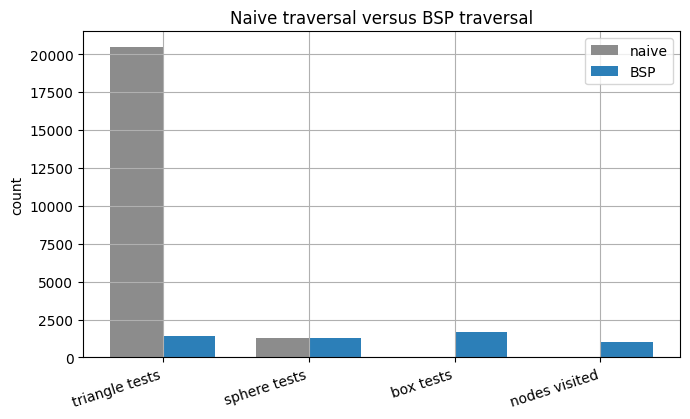

In [11]:
probe_width, probe_height = 24, 18
probe_rays = camera_rays(camera, probe_width, probe_height)
naive_total = IntersectStats()
bsp_total = IntersectStats()
agreement = 0
for probe_ray in probe_rays:
    h0, s0 = intersect_scene(meshes, probe_ray, use_bsp=False)
    h1, s1 = intersect_scene(meshes, probe_ray, trees=trees, use_bsp=True)
    naive_total.add(s0)
    bsp_total.add(s1)
    if h0 is None and h1 is None:
        agreement += 1
    elif h0 is not None and h1 is not None and h0.mesh_name == h1.mesh_name and np.isclose(h0.t, h1.t):
        agreement += 1
print("rays:", len(probe_rays), "agreements:", agreement)
print("naive:", naive_total.as_dict())
print("bsp:", bsp_total.as_dict())
assert agreement == len(probe_rays)
assert bsp_total.triangle_tests < naive_total.triangle_tests

fig, ax = plt.subplots(figsize=(7, 4.3))
labels = ["triangle tests", "sphere tests", "box tests", "nodes visited"]
naive_values = [naive_total.triangle_tests, naive_total.sphere_tests, naive_total.box_tests, naive_total.nodes_visited]
bsp_values = [bsp_total.triangle_tests, bsp_total.sphere_tests, bsp_total.box_tests, bsp_total.nodes_visited]
x = np.arange(len(labels))
ax.bar(x - 0.18, naive_values, 0.36, label="naive", color="#8c8c8c")
ax.bar(x + 0.18, bsp_values, 0.36, label="BSP", color="#2c7fb8")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=18, ha="right")
ax.set_ylabel("count")
ax.set_title("Naive traversal versus BSP traversal")
ax.legend()
fig.tight_layout()
accel_png = remember("acceleration_counts_png", save_matplotlib(fig, "chapter-23", "figures", "acceleration-counts.png", root=ARTIFACT_ROOT))
plt.show()


## Surface Normals, Shadows, And Shading

After intersection, the renderer switches to shading. The hit record supplies the point, face index, barycentric coordinates, material, and normal. For smooth shading, the normal is the barycentric interpolation of vertex normals, normalized again before use. This changes lighting, not the actual polygonal shape.

The shader here is a compact OpenGL-style model: ambient, diffuse, and specular. Diffuse light uses the cosine between the surface normal and the light direction. Specular light uses a reflected light direction and the view direction. A shadow ray is spawned from just above the surface point toward each light. If another surface blocks that finite segment, the light does not contribute diffuse or specular color.


In [12]:
shading_ray = camera.ray(-0.28, -0.02)
shading_hit, shading_stats = intersect_scene(meshes, shading_ray, trees=trees, use_bsp=True)
assert shading_hit is not None
local_color, shadow_stats = shade_hit(shading_hit, shading_ray, meshes, lights, trees=trees, use_bsp=True, shadows=True)
print("hit:", shading_hit.mesh_name, shading_hit.point)
print("normal:", shading_hit.normal, "length:", np.linalg.norm(shading_hit.normal))
print("barycentric:", shading_hit.barycentric, "sum:", shading_hit.barycentric.sum())
print("color:", local_color)
assert np.isclose(np.linalg.norm(shading_hit.normal), 1.0)
assert np.isclose(shading_hit.barycentric.sum(), 1.0)
assert np.all((local_color >= 0) & (local_color <= 1))

fig_shade = go.Figure()
for mesh in meshes:
    fig_shade.add_trace(mesh_surface_trace(mesh, opacity=0.25))
fig_shade.add_trace(ray_trace(shading_ray, 0, shading_hit.t, "view ray", "#111111"))
fig_shade.add_trace(go.Scatter3d(x=[shading_hit.point[0]], y=[shading_hit.point[1]], z=[shading_hit.point[2]], mode="markers+text", text=["surface point"], marker={"size": 6, "color": "#000000"}, name="surface point"))
normal_end = shading_hit.point + 0.55 * shading_hit.normal
fig_shade.add_trace(go.Scatter3d(x=[shading_hit.point[0], normal_end[0]], y=[shading_hit.point[1], normal_end[1]], z=[shading_hit.point[2], normal_end[2]], mode="lines", name="normal", line={"color": "#2ca02c", "width": 8}))
for idx, light in enumerate(lights):
    fig_shade.add_trace(go.Scatter3d(x=[shading_hit.point[0], light.position[0]], y=[shading_hit.point[1], light.position[1]], z=[shading_hit.point[2], light.position[2]], mode="lines", name=f"shadow ray {idx}", line={"color": "#ffbf00", "width": 4}))
fig_shade.update_layout(title="Hit point, interpolated normal, and shadow rays", scene={"aspectmode": "data"}, margin={"l": 0, "r": 0, "b": 0, "t": 45})
shading_html = remember("shading_geometry_html", save_plotly_html(fig_shade, "chapter-23", "figures", "shading-geometry.html", root=ARTIFACT_ROOT))
display_artifact(shading_html, height=520)


hit: red sphere mesh [-0.3347 -0.1596  0.769 ]
normal: [ 0.4723 -0.0117  0.8814] length: 1.0
barycentric: [0.8333 0.1217 0.045 ] sum: 0.9999999999999999
color: [0.1622 0.0424 0.032 ]
shading_geometry_html: artifacts/chapter-23/figures/shading-geometry.html


## Reflection And Refraction Directions

Reflection and refraction are ray-spawning rules. Reflection flips the normal component of the incoming direction while preserving length. In geometric algebra, reflection can be written as a sandwich operation with a reflecting object. In the coordinate shader, it is a direct vector formula with the same geometric invariant: the angle with the normal changes sign.

Refraction uses Snell's law. The helper returns `None` when total internal reflection occurs. The mini renderer below uses reflection but does not render transparent solids; the refraction check is included because reflective, refractive, and shadow rays are the three classic spawned rays in a simple ray tracer.


In [13]:
incident = normalize(np.array([0.35, -0.75, -0.56]))
surface_normal = normalize(np.array([0.0, 1.0, 0.0]))
reflected = reflect_direction(incident, surface_normal)
refracted = refract_direction(incident, surface_normal, eta_in_over_out=1.0 / 1.5)
assert refracted is not None
assert np.isclose(np.linalg.norm(reflected), 1.0)
assert np.isclose(np.linalg.norm(refracted), 1.0)
assert np.isclose(np.dot(incident, surface_normal), -np.dot(reflected, surface_normal))
internal = refract_direction(normalize(np.array([0.92, 0.12, 0.37])), -surface_normal, eta_in_over_out=1.5)
print("incident:", incident)
print("reflected:", reflected)
print("refracted:", refracted)
print("total internal reflection result:", internal)
assert internal is None


incident: [ 0.3502 -0.7505 -0.5604]
reflected: [ 0.3502  0.7505 -0.5604]
refracted: [ 0.2335 -0.8977 -0.3736]
total internal reflection result: None


## Mini Rendering Lab

The pieces now form a small renderer. For each pixel, the camera spawns a primary ray. The scene intersection routine checks bounding spheres, traverses BSP trees, and tests triangles. The shader interpolates a normal, sends shadow rays toward lights, computes ambient, diffuse, and specular color, and traces one reflected bounce when the material asks for it.

The renderer is intentionally modest. It has no texture maps, no supersampling, no glossy reflection distribution, and no transparent solids. That restraint keeps the chapter readable. The essential geometric pipeline is visible: ray spawning, rejection, spatial traversal, triangle intersection, local surface data, shadow rays, reflected rays, and final color.


image shape: (84, 112, 3)
render stats: {'sphere_tests': 68979, 'box_tests': 159565, 'triangle_tests': 130938, 'nodes_visited': 85233, 'leaves_visited': 23796}
mini_render_png: artifacts/chapter-23/render/mini-render.png
render_stats_json: artifacts/chapter-23/render/render-stats.json


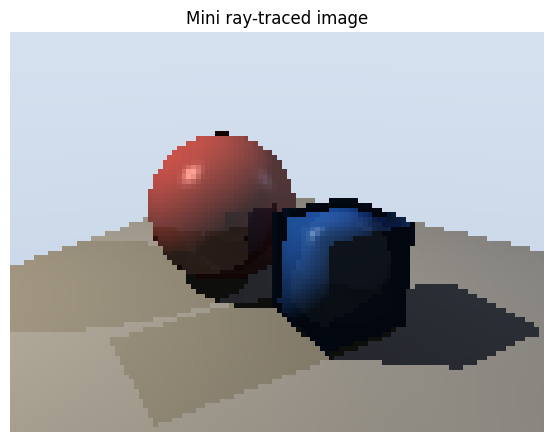

In [14]:
render_width, render_height = 112, 84
image, render_stats = render_scene(
    meshes,
    lights,
    camera,
    width=render_width,
    height=render_height,
    trees=trees,
    use_bsp=True,
    max_depth=1,
)
print("image shape:", image.shape)
print("render stats:", render_stats.as_dict())
assert image.shape == (render_height, render_width, 3)
assert float(image.max()) > float(image.min())

render_path = artifact_path("chapter-23", "render", "mini-render.png", root=ARTIFACT_ROOT)
plt.imsave(render_path, np.clip(image, 0, 1))
remember("mini_render_png", render_path)
remember("render_stats_json", save_json(render_stats.as_dict(), "chapter-23", "render", "render-stats.json", root=ARTIFACT_ROOT))

fig, ax = plt.subplots(figsize=(7, 5.2))
ax.imshow(np.clip(image, 0, 1))
ax.set_axis_off()
ax.set_title("Mini ray-traced image")
plt.show()


## Reading The Image

The image is small, but it contains the chapter's main geometry. The red object is a triangle mesh with smoothed normals. The blue box is a transformed model. The floor receives shadows because the shader tests finite segments from surface points to lights. Reflected contribution appears where a material asks for it. The background is returned when a primary or reflected ray misses the scene.

One pixel may use almost every representation in the translation guide: a camera ray, a bounding sphere, a BSP traversal, a triangle hit, barycentric weights, an interpolated normal, a shadow segment, a reflected ray, and vector lighting. The conformal model gives those objects a shared geometric home; the renderer stores each one in a form suited to its repeated operation.


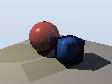

In [15]:
display_artifact(render_path, width=640)


## Final Sanity Checks

The final cell checks the notebook as an executable chapter artifact. It verifies the source-span note, conformal distance identity, mesh invariants, BSP construction, agreement between naive and BSP traversal on a ray bundle, reflection and refraction invariants, render image shape, and artifact existence. The checks repeat earlier assertions on purpose. Readers often edit and rerun selected sections, and the final cell should catch inconsistent state before the notebook is treated as complete.


In [16]:
verified_pdf_pages = (577, 601)
verified_printed_pages_present_in_pdf = (557, 581)
requested_printed_neighborhood = (557, 584)
assert verified_pdf_pages == (577, 601)
assert verified_printed_pages_present_in_pdf[0] == requested_printed_neighborhood[0]

for p, q in [(np.zeros(3), np.array([1.0, 2.0, -1.0])), (a, b)]:
    assert np.isclose(cga_distance_squared(p, q), np.sum((p - q) ** 2))
    assert np.isclose(cga_inner(cga_point(p), cga_point(p)), 0.0)

for mesh in meshes:
    assert mesh.triangle_count > 0
    assert np.all(mesh.face_areas > 0)
    assert bsp_leaf_count(trees[mesh.name]) >= 1

assert agreement == len(probe_rays)
assert bsp_total.triangle_tests < naive_total.triangle_tests
assert np.isclose(np.linalg.norm(reflected), 1.0)
assert np.isclose(np.linalg.norm(refracted), 1.0)
assert internal is None
assert image.shape == (render_height, render_width, 3)

required_artifacts = {
    "mesh_overview_html",
    "mesh_checks_json",
    "scene_transform_html",
    "camera_rays_html",
    "triangle_intersection_html",
    "bsp_planes_html",
    "bsp_summary_json",
    "acceleration_counts_png",
    "shading_geometry_html",
    "mini_render_png",
    "render_stats_json",
}
assert required_artifacts.issubset(written_artifacts)
for name in required_artifacts:
    path = written_artifacts[name]
    assert path.exists(), path
    assert path.stat().st_size > 0, path

sanity = {
    "verified_pdf_pages": verified_pdf_pages,
    "verified_printed_pages_present_in_pdf": verified_printed_pages_present_in_pdf,
    "requested_printed_neighborhood": requested_printed_neighborhood,
    "note": "PDF jumps from printed page 581 to Appendix A printed page 585; no extractable printed pages 582-584 were present.",
    "artifact_count": len(written_artifacts),
    "render_shape": list(image.shape),
    "probe_rays": len(probe_rays),
    "naive_triangle_tests": naive_total.triangle_tests,
    "bsp_triangle_tests": bsp_total.triangle_tests,
}
remember("final_sanity_json", save_json(sanity, "chapter-23", "checks", "final-sanity.json", root=ARTIFACT_ROOT))
print(json.dumps(sanity, indent=2))


final_sanity_json: artifacts/chapter-23/checks/final-sanity.json
{
  "verified_pdf_pages": [
    577,
    601
  ],
  "verified_printed_pages_present_in_pdf": [
    557,
    581
  ],
  "requested_printed_neighborhood": [
    557,
    584
  ],
  "note": "PDF jumps from printed page 581 to Appendix A printed page 585; no extractable printed pages 582-584 were present.",
  "artifact_count": 11,
  "render_shape": [
    84,
    112,
    3
  ],
  "probe_rays": 432,
  "naive_triangle_tests": 20472,
  "bsp_triangle_tests": 1408
}


## Chapter Takeaways

Ray tracing is a strong test of geometric algebra because many geometric objects appear in one pipeline. Points, rays, planes, spheres, meshes, normals, transformations, reflections, refractions, and visibility tests all arise naturally. A common algebraic model helps us understand them as parts of one system instead of as unrelated formulas.

The application lesson is contextual representation. The conformal model may be the cleanest way to describe an object, but a renderer may store a cheaper stand-in when the repeated operation is clear. A point-direction ray is efficient for closest-hit queries. Vertex arrays and face indices are efficient for mesh traversal. Barycentric coordinates are efficient for interpolation. A bounding sphere is efficient for rejection. A BSP tree is efficient because it trades many triangle tests for cheaper spatial interval tests.

The right habit is to let the algebra name the geometry, expose invariants, and guide transformations, then choose implementation forms that serve the computation. This notebook uses conformal distance checks, object-level transformation language, and geometric sanity assertions while rendering with plain arrays. That is the bridge from geometric algebra as a language of objects to geometric algebra as a practical design tool for computer graphics software.
